# Row 5: More same-day-expiry gamma at 15:30, quieter last half hour; the 0DTE layer is larger than the standing book

In [1]:
import sys, json, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
sys.path.insert(0, "../gex_history")
import rows as R, gexlib as G
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
ctx = R.load("spy", with_chain=True)
print(ctx["sym"], len(ctx["daily"]), "days")

SPY 751 days


{
 "n_day_buckets": 9659,
 "n_days": 743,
 "median_contracts_per_day": 68.0,
 "spearman_next_range": {
  "stale": -0.4287268803677415,
  "remark": -0.5179344148479462,
  "remark_plus_0dte_signed": -0.514346404884229,
  "unsigned_0dte_alone": -0.29368179924284027,
  "signed_0dte_alone": -0.3601872880549699
 },
 "joint_regression_t": {
  "remark_rank": -13.018570111683298,
  "u0dte_rank": -5.445905091726211,
  "s0dte_rank": 0.21498317113983817
 },
 "joint_regression_coef": {
  "remark_rank": -1.1926951964374146,
  "u0dte_rank": -0.6188026048881037,
  "s0dte_rank": 0.01466538672532553
 },
 "last_half_hour_by_0dte_exposure_at_1530": {
  "prev_positive": {
   "n": 310,
   "last_half_hour_range_adj_low_0dte": 1.1178180335229608,
   "high_0dte": 0.8767856429777925,
   "diff_high_minus_low": -0.24103239054516834,
   "ci_lo": -0.4180875855741599,
   "ci_hi": -0.07841796656660283,
   "p_mwu": 0.0010981253200143697,
   "spearman_ugex_vs_last_range": -0.22572548672085138,
   "spearman_signed_vs_la

,ugex_0dte_bn,book_abs_bn,share_0dte,net_0dte_positive_share
bucket,,,,
0,5.600,4.202,0.598,0.598
1,5.608,4.229,0.591,0.579
2,5.464,4.374,0.583,0.573
3,5.488,4.346,0.586,0.580
4,5.431,4.409,0.586,0.600
5,5.403,4.508,0.578,0.590
6,5.423,4.514,0.572,0.579
7,5.359,4.490,0.566,0.592
8,5.418,4.525,0.565,0.583


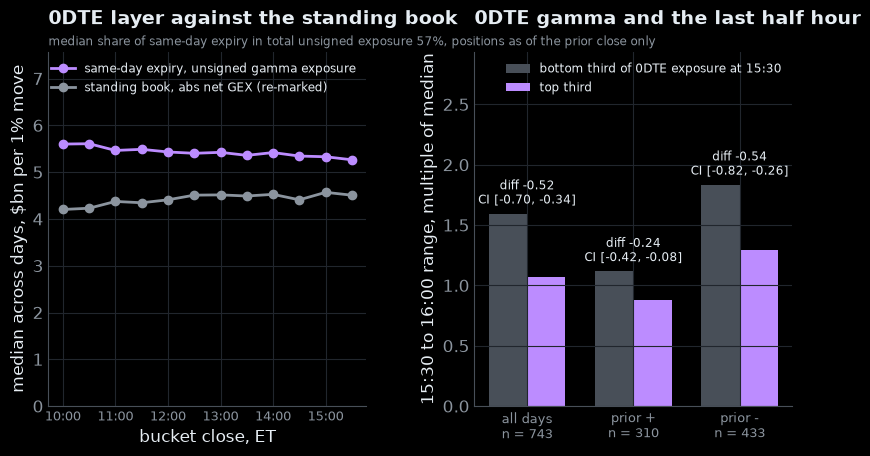

In [2]:
res = R.row5(ctx)
print(json.dumps({k: v for k, v in R.show(res['t8']).items() if k != 'by_bucket'}, indent=1))
print(json.dumps(R.show(res['controls']), indent=1))
display(pd.DataFrame(res['t8']['by_bucket']).set_index('bucket').round(3))
_ = R.fig5(ctx, res, G.FIGURES / 'row05_zero_dte.png')

In [3]:
R.per_name({'r5_days_with_0dte': 'days with same-day expiry', 'r5_share_0dte_of_book_1000': '0DTE share of gamma at 10:00', 'r5_spearman_1530_last': 'Spearman, 15:30 exposure vs last half hour', 'r5_last_low': 'last half hour, low third', 'r5_last_high': 'high third', 'r5_last_p': 'p'}).round(3)

,days with same-day expiry,0DTE share of gamma at 10:00,"Spearman, 15:30 exposure vs last half hour","last half hour, low third",high third,p
symbol,,,,,,
SPY,743,0.598,-0.306,1.595,1.073,0.000
QQQ,248,0.588,-0.152,1.442,1.087,0.006
IWM,248,0.308,-0.139,1.268,1.036,0.005
NVDA,111,0.391,0.012,1.073,1.121,0.854
TSLA,112,0.623,-0.216,1.283,1.129,0.022
AAPL,114,0.345,-0.124,1.175,1.190,0.282
AMZN,114,0.344,-0.150,1.235,1.030,0.182
META,112,0.531,-0.201,1.105,1.077,0.205
MSFT,112,0.433,-0.223,1.407,1.086,0.039
